In [1]:
import sys
sys.path.insert(0, '/home/ethantu/workspace/good-vibrations/src3')

from dataset import DATA_INFO, build_dataset, VibrationDataset
from model import VibrationTransformer
from callbacks import OutputSaver

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
import json, math, base64, io
from pathlib import Path

from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.signal import find_peaks
from PIL import Image
from composer import Trainer
from composer.core import Evaluator

# 0. Run + Dataset configuration

In [3]:
NORMALIZE_MODE = 'z-global'  # must match the normalize_mode the run's data was processed with

In [4]:
# ── Run configuration ──────────────────────────────────────────────────────────────
# Set exactly one of these to identify the run, or none for dataset-only mode.
# Priority: FORWARD_OUTPUTS_DIR > MODEL_CHECKPOINT_PATH > RUN_NAME
#
#   FORWARD_OUTPUTS_DIR   — path to saved .pt outputs; skips inference entirely
#   MODEL_CHECKPOINT_PATH — absolute path to a .pt checkpoint; runs inference
#   RUN_NAME               — name of a run under RUNS_ROOT; uses latest checkpoint
#   DO_INFERENCE           — set False to force dataset-only mode regardless
# ──────────────────────────────────────────────────────────────
RUNS_ROOT = Path('/home/ethantu/workspace/good-vibrations/runs')

# RUN_NAME              = '1782932961-heavenly-vole'
RUN_NAME = '1783000020-straight-cougar'
MODEL_CHECKPOINT_PATH = None
FORWARD_OUTPUTS_DIR   = None
DO_INFERENCE          = None

In [5]:
# MDS path this run was trained on (see src3/wandb/<run>/files/config.yaml -> mds_path).
# For 1782976494-solid-mayfly (wandb run-20260702_101454-1kd8cfrm) this was
# ../mds/70f14df175f6408d (relative to src3/), i.e. mds/70f14df175f6408d at the repo root.
MDS_PATH = '/home/ethantu/workspace/good-vibrations/data/mds/c1650bbbf41d93b8'

# Directory of overhead photos + full-res segmentation masks per sample (not stored in the
# MDS itself — the MDS only has the processed/tokenized fft (X.npy) and the downsampled
# mask (y.npy)). Layout: SAMPLES_OVERHEAD_DIR/<sample_id:06d>/{01_resized_overhead.png, 02_segment_mask.png}
# Set to None to skip overhead/segment-mask lookups.
SAMPLES_OVERHEAD_DIR = '/home/ethantu/workspace/good-vibrations/data/samples_overhead'

In [41]:
SPLITS = ['train', 'eval/unseen_pos_speaker', 'eval/unseen_pos', 'eval/unseen_layout']

In [7]:
# Bin sizes in mask pixels for grouping analysis. true_cx ∈ [0, out_w), true_cy ∈ [0, out_h).
epsilon = 0.05
COM_BIN_SIZE_X = 1.6 - epsilon
COM_BIN_SIZE_Y = 2

# 1. Load MDS Dataset

In [8]:
# dataset.jsonl sidecar: first line is data_info (out_h, out_w, n_samples, ...), rest are index_rows.
# sample_id is stored zero-padded ("000000") in the sidecar but as int in the MDS itself
# (see VibrationDataset / tensor_store keys) — cast here so the two line up.
_lines = (Path(MDS_PATH) / 'dataset.jsonl').read_text().strip().splitlines()
data_info = json.loads(_lines[0])
index_rows = [json.loads(line) for line in _lines[1:] if line]
for _row in index_rows:
    _row['sample_id'] = int(_row['sample_id'])
MASK_H, MASK_W = data_info['out_h'], data_info['out_w']
print(f'data_info={data_info}')
print(f'loaded {len(index_rows)} index_rows')

data_info={'out_h': 18, 'out_w': 44, 'n_samples': 688, 'n_laser_rows': 10, 'n_laser_cols': 10, 'patch_size': 256, 'n_freqs': 3328}
loaded 688 index_rows


In [9]:
# tensor_store: single source of truth for mask_true (+ fft/overhead when RAW_DATA_DIR is set), keyed by sample_id
raw_dataset = VibrationDataset(local=MDS_PATH)

tensor_store = {}
for i, row in enumerate(index_rows):
    sid = row['sample_id']
    item = raw_dataset[i]
    tensor_store[sid] = {
        'fft':       item['fft'].numpy(),        # (L, P, PS, 2) float32 — already processed (magnitude-extracted, normalized, tokenized)
        'mask_true': item['mask_true'].numpy(),   # (MASK_H, MASK_W) float32, values in [0, 1]
    }
print(f'loaded {len(tensor_store)} samples  mask shape: {tensor_store[index_rows[0]["sample_id"]]["mask_true"].shape}')

/home/ethantu/workspace/good-vibrations/src3/dataset.py:137: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return dict(fft=torch.from_numpy(X), mask_true=torch.from_numpy(y), info=info)


loaded 688 samples  mask shape: (18, 44)


In [10]:
# Optional: wire up overhead photos + full-res segmentation masks from SAMPLES_OVERHEAD_DIR.
# On-disk sample dirs are named f'{sample_id:06d}', matching the MDS's int sample_id
# (int('000008') == 8).
#
# Use 01_resized_overhead.png (clean photo, no mask/speaker baked in) rather than a
# speaker-composited overhead image, which has the segmentation mask and speaker icon
# photoshopped in already — that would visually collide with the mask_true/mask_pred
# overlays plotted on top in plot_predictions.
overhead_img_paths, seg_mask_paths = {}, {}

if SAMPLES_OVERHEAD_DIR is not None:
    samples_dir = Path(SAMPLES_OVERHEAD_DIR)
    for sid in tensor_store:
        sample_dir = samples_dir / f'{sid:06d}'
        overhead_path = sample_dir / '01_resized_overhead.png'
        seg_mask_path = sample_dir / '02_segment_mask.png'
        if overhead_path.exists(): overhead_img_paths[sid] = overhead_path
        if seg_mask_path.exists(): seg_mask_paths[sid] = seg_mask_path
    print(f'overhead images found:         {len(overhead_img_paths)}/{len(tensor_store)}')
    print(f'full-res segment masks found:  {len(seg_mask_paths)}/{len(tensor_store)}')
else:
    print('SAMPLES_OVERHEAD_DIR not set — skipping overhead/segment-mask lookups')

overhead images found:         688/688
full-res segment masks found:  688/688


In [11]:
# --- Part 1: Dataset rows (always populated) ---
# Columns from MDS index (always): sample_id, n_objects, speaker, box, is_empty_box, object,
#   downsampled_com_x, downsampled_com_y
# Computed from tensor_store (always): true_x_com, true_y_com, bin_cx, bin_cy

def com(mask):
    s = mask.sum()
    if s == 0: return float('nan'), float('nan')
    cx = float(np.average(np.arange(mask.shape[1]), weights=mask.sum(0)))
    cy = float(np.average(np.arange(mask.shape[0]), weights=mask.sum(1)))
    return cx, cy

def _bin_com(v, size):
    return round(v / size) * size if v is not None and not np.isnan(v) else None

rows = []
for row in index_rows:
    sid = row['sample_id']
    mt = tensor_store[sid]['mask_true']
    tx, ty = com(mt)
    rows.append({
        'sample_id':    sid,
        'n_objects':    row['n_objects'],
        'speakers':     row['speaker'],
        'box':          row['box'],
        'is_empty_box': row['is_empty_box'],
        'object':       row['object'],
        'true_x_com':   tx,
        'true_y_com':   ty,
        'bin_cx':       _bin_com(tx, COM_BIN_SIZE_X),
        'bin_cy':       _bin_com(ty, COM_BIN_SIZE_Y),
    })

df = pd.DataFrame(rows)
df

,sample_id,n_objects,speakers,box,is_empty_box,object,true_x_com,true_y_com,bin_cx,bin_cy
0,0,1,1,metal,False,cube,11.927178,12.635312,12.4,12.0
1,1,1,2,metal,False,cube,11.927178,12.635312,12.4,12.0
2,2,1,3,metal,False,cube,11.927178,12.635312,12.4,12.0
3,3,1,4,metal,False,cube,11.927178,12.635312,12.4,12.0
4,4,1,5,metal,False,cube,11.927178,12.635312,12.4,12.0
...,...,...,...,...,...,...,...,...,...,...
683,683,0,4,metal,True,,NaN,NaN,NaN,NaN
684,684,0,5,metal,True,,NaN,NaN,NaN,NaN
685,685,0,6,metal,True,,NaN,NaN,NaN,NaN
686,686,0,7,metal,True,,NaN,NaN,NaN,NaN


# 2 Inference

In [12]:
def parse_run_config():
    """Resolve config variables into (do_inference, checkpoint_path, forward_outputs_dir)."""
    if DO_INFERENCE is False:
        return False, None, None

    if FORWARD_OUTPUTS_DIR:
        p = Path(FORWARD_OUTPUTS_DIR)
        assert p.exists(), f'FORWARD_OUTPUTS_DIR does not exist: {p}'
        return False, None, p

    if MODEL_CHECKPOINT_PATH:
        ckpt = Path(MODEL_CHECKPOINT_PATH)
        assert ckpt.exists(), f'MODEL_CHECKPOINT_PATH does not exist: {ckpt}'
        run_dir = RUNS_ROOT / ckpt.parent.parent.name  # runs/<name>/checkpoints/<file>
        out_dir = run_dir / 'forward_outputs'
        return True, ckpt, out_dir

    if RUN_NAME:
        run_dir = RUNS_ROOT / RUN_NAME
        assert run_dir.exists(), f'Run not found: {run_dir}'
        ckpt = run_dir / 'checkpoints' / 'latest-rank0.pt'
        assert ckpt.exists(), f'Checkpoint not found: {ckpt}'
        out_dir = run_dir / 'forward_outputs'
        return True, ckpt, out_dir

    raise ValueError('DO_INFERENCE=True but none of RUN_NAME / MODEL_CHECKPOINT_PATH / FORWARD_OUTPUTS_DIR is set')

_do_inference, _checkpoint_path, _forward_outputs_dir = parse_run_config()
print(f'do_inference={_do_inference}')
print(f'checkpoint  ={_checkpoint_path}')
print(f'outputs_dir ={_forward_outputs_dir}')

do_inference=True
checkpoint  =/home/ethantu/workspace/good-vibrations/runs/1783000020-straight-cougar/checkpoints/latest-rank0.pt
outputs_dir =/home/ethantu/workspace/good-vibrations/runs/1783000020-straight-cougar/forward_outputs


In [13]:
import gc
import psutil, os as _os

def _log_mem(tag):
    proc = psutil.Process(_os.getpid())
    rss_gb = proc.memory_info().rss / 1e9
    if torch.cuda.is_available():
        vram_alloc = torch.cuda.memory_allocated() / 1e9
        vram_res   = torch.cuda.memory_reserved()  / 1e9
        print(f'[mem] {tag}: RSS={rss_gb:.2f} GB  VRAM alloc={vram_alloc:.2f} GB  reserved={vram_res:.2f} GB')
    else:
        print(f'[mem] {tag}: RSS={rss_gb:.2f} GB')

def run_inference(checkpoint_path, forward_outputs_dir):
    """Run a full eval pass and save .pt outputs. Returns forward_outputs_dir."""
    forward_outputs_dir = Path(forward_outputs_dir)
    forward_outputs_dir.mkdir(parents=True, exist_ok=True)

    # num_workers=0 (no persistent worker subprocesses): this is a single one-off eval
    # pass, not training, so we don't need loader parallelism — and worker teardown
    # (persistent_workers=True + pin_memory=True) has been observed to kill the Jupyter
    # kernel itself on cleanup (QueueFeederThread "Bad file descriptor" / semaphore errors).
    train_loader, eval_loaders, _ = build_dataset(MDS_PATH, batch_size=600, eval_batch_size=600, num_workers=0)

    data_loaders = eval_loaders + [Evaluator(label='train', dataloader=train_loader)]
    trainer = Trainer(
        model=VibrationTransformer(data_info=data_info),
        load_path=str(checkpoint_path),
        callbacks=OutputSaver('1ep', str(forward_outputs_dir), overwrite=True),
        progress_bar=False,
    )
    trainer.eval(data_loaders)
    _log_mem('after trainer.eval')

    trainer.close()

    # 1. Move model off GPU and clear last-batch tensors before dropping references.
    #    trainer.state.model is Composer's wrapped object — not the VibrationTransformer()
    #    we passed in. Clearing outputs/batch drops the live activations.
    trainer.state.model.cpu()
    trainer.state.outputs = None
    trainer.state.batch   = None

    # 2. Drop all Python references so refcounts hit zero.
    del trainer, data_loaders, eval_loaders, train_loader

    # 3. Collect any reference cycles (DataLoader/Dataset can form them).
    gc.collect()

    # 4. Return the now-unallocated CUDA pages to the OS.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    _log_mem('after cleanup')
    return forward_outputs_dir

if _do_inference:
    _forward_outputs_dir = run_inference(_checkpoint_path, _forward_outputs_dir)

688 total samples, 688 after filtering -> train=511, eval/unseen_pos_speaker=33, eval/unseen_pos=96, eval/unseen_layout=48


/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/trainer/trainer.py:1224: UserWarning: No optimizer was specified. Defaulting to DecoupledSGDW(lr=0.1)
  warnings.warn((


/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/state.py:1580: UserWarning: OutputSaver is not in the state_dict. Its state will not be restored.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/state.py:1388: UserWarning: DecoupledSGDW is not in the state_dict. Its state will not be restored.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 33 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:29: UserWarning: Cannot split list of length 33 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batc

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 96 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:29: UserWarning: Cannot split list of length 96 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 48 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnin

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:40: UserWarning: Cannot split tensor of length 511 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/composer/core/data_spec.py:29: UserWarning: Cannot split list of length 511 into batches of size 600. As it is smaller, no splitting will be done. This may happen on the last batch of a dataset if it is a smaller size than the microbatch size.
  warnings.warn(


[mem] after trainer.eval: RSS=6.08 GB  VRAM alloc=1.38 GB  reserved=13.05 GB


[mem] after cleanup: RSS=6.09 GB  VRAM alloc=0.01 GB  reserved=0.03 GB


# 3 Load Forward Outputs

In [14]:
def load_forward_outputs(forward_outputs_dir):
    """Load saved .pt output files. Returns run_name and run_data dict."""
    forward_outputs_dir = Path(forward_outputs_dir)
    def _most_recent(d): return max(d.iterdir(), key=lambda p: p.stat().st_mtime)

    run_name = forward_outputs_dir.parent.name  # runs/<run_name>/forward_outputs
    run_data = {}
    for split in SPLITS:
        split_dir = forward_outputs_dir / split
        if not split_dir.exists():
            print(f'  skipping {split} (no outputs found)')
            continue
        path = _most_recent(split_dir)
        print(f'  loading {split} <- {path.name}')
        output = torch.load(path)
        output |= output.pop('info').items()
        run_data |= {f'{split}/{k}': v for k, v in output.items()}
    return run_name, run_data


run_data = {}
RUN_NAME_LOADED = None

if _forward_outputs_dir is not None:
    RUN_NAME_LOADED, run_data = load_forward_outputs(_forward_outputs_dir)
    print(f'Loaded run: {RUN_NAME_LOADED}')
else:
    print('Dataset-only mode — no run loaded')

  loading train <- ep10000-ba080000.pt
  loading eval/unseen_pos_speaker <- ep10000-ba080000.pt
  loading eval/unseen_layout <- ep10000-ba080000.pt


  loading eval/unseen_pos <- ep10000-ba080000.pt
Loaded run: 1783000020-straight-cougar


In [15]:
run_data.keys()

dict_keys(['train/fft', 'train/mask_pred', 'train/mask_true', 'train/sample_id', 'train/output_id', 'train/n_objects', 'train/speaker', 'train/box', 'train/is_empty_box', 'train/x_com', 'train/y_com', 'eval/unseen_pos_speaker/fft', 'eval/unseen_pos_speaker/mask_pred', 'eval/unseen_pos_speaker/mask_true', 'eval/unseen_pos_speaker/sample_id', 'eval/unseen_pos_speaker/output_id', 'eval/unseen_pos_speaker/n_objects', 'eval/unseen_pos_speaker/speaker', 'eval/unseen_pos_speaker/box', 'eval/unseen_pos_speaker/is_empty_box', 'eval/unseen_pos_speaker/x_com', 'eval/unseen_pos_speaker/y_com', 'eval/unseen_layout/fft', 'eval/unseen_layout/mask_pred', 'eval/unseen_layout/mask_true', 'eval/unseen_layout/sample_id', 'eval/unseen_layout/output_id', 'eval/unseen_layout/n_objects', 'eval/unseen_layout/speaker', 'eval/unseen_layout/box', 'eval/unseen_layout/is_empty_box', 'eval/unseen_layout/x_com', 'eval/unseen_layout/y_com', 'eval/unseen_pos/fft', 'eval/unseen_pos/mask_pred', 'eval/unseen_pos/mask_true

In [16]:
def build_df_run(run_data):
    """Parse run_data into df_run and store mask_preds in tensor_store."""
    # sanity check: mask_true in run .pt must match the MDS
    print('Sanity checking mask_true (run .pt vs MDS)...')
    n_checked = n_mismatch = 0
    for split in SPLITS:
        if f'{split}/sample_id' not in run_data: continue
        for i in range(len(run_data[f'{split}/sample_id'])):
            sid = run_data[f'{split}/sample_id'][i].item()
            if sid not in tensor_store: continue
            mt_run = np.asarray(run_data[f'{split}/mask_true'][i], dtype=float)
            mt_mds = np.asarray(tensor_store[sid]['mask_true'], dtype=float)
            if not np.allclose(mt_run, mt_mds, atol=1e-4):
                print(f'  MISMATCH  sample_id={sid}  split={split}  max_diff={np.abs(mt_run-mt_mds).max():.5f}')
                n_mismatch += 1
            n_checked += 1
    print(f'  checked {n_checked} samples, {n_mismatch} mismatches')

    def _mcom(arr, bmask):
        sub = arr * bmask; s = sub.sum()
        if s < 1e-9: return float('nan'), float('nan')
        H, W = arr.shape
        return float((sub.sum(0)*np.arange(W)).sum()/s), float((sub.sum(1)*np.arange(H)).sum()/s)

    run_rows = []
    for split in SPLITS:
        if f'{split}/sample_id' not in run_data: continue
        for i in range(len(run_data[f'{split}/sample_id'])):
            sid = run_data[f'{split}/sample_id'][i].item()

            mt = np.asarray(tensor_store[sid]['mask_true'], dtype=float)
            mp = np.asarray(run_data[f'{split}/mask_pred'][i], dtype=float)

            # store mask_pred in tensor_store (single source of truth)
            tensor_store[sid]['mask_pred'] = mp

            tx, ty = com(mt)
            px_, py_ = com(mp)
            dx, dy = px_ - tx, py_ - ty
            zero_mask, nonzero_mask = mt == 0, mt > 0
            pcx_nz, pcy_nz = _mcom(mp, nonzero_mask)
            tcx_nz, tcy_nz = _mcom(mt, nonzero_mask)

            output_id = run_data.get(f'{split}/output_id')
            run_rows.append({
                'split':         split,
                'sample_id':     sid,
                'output_id':     output_id[i] if output_id is not None else None,
                'mse':           float(np.mean((mp - mt) ** 2)),
                'mse_gt0':       float(np.mean((mp[nonzero_mask] - mt[nonzero_mask]) ** 2)) if nonzero_mask.any() else float('nan'),
                'pred_x_com':    px_,
                'pred_y_com':    py_,
                'x_com_diff':    dx,
                'y_com_diff':    dy,
                'com_dist':      float(np.hypot(dx, dy)) if not (np.isnan(dx) or np.isnan(dy)) else float('nan'),
                'pred_mass_gt0': float(mp[nonzero_mask].sum()) if nonzero_mask.any() else float('nan'),
            })

    return pd.DataFrame(run_rows)

if run_data:
    df_run = build_df_run(run_data)
    df = df.merge(df_run, on='sample_id', how='left')
df

Sanity checking mask_true (run .pt vs MDS)...
  checked 688 samples, 0 mismatches


,sample_id,n_objects,speakers,box,is_empty_box,object,true_x_com,true_y_com,bin_cx,bin_cy,split,output_id,mse,mse_gt0,pred_x_com,pred_y_com,x_com_diff,y_com_diff,com_dist,pred_mass_gt0
0,0,1,1,metal,False,cube,11.927178,12.635312,12.4,12.0,eval/unseen_pos,000000,1.083159e-01,0.789595,21.518442,8.378707,9.591264,-4.256606,10.493381,2.078882
1,1,1,2,metal,False,cube,11.927178,12.635312,12.4,12.0,eval/unseen_pos,000000,6.067492e-02,0.320846,15.268784,11.099530,3.341606,-1.535782,3.677629,38.911858
2,2,1,3,metal,False,cube,11.927178,12.635312,12.4,12.0,eval/unseen_pos,000000,8.424736e-02,0.409216,16.097737,10.988018,4.170559,-1.647294,4.484098,34.362966
3,3,1,4,metal,False,cube,11.927178,12.635312,12.4,12.0,eval/unseen_pos,000000,6.987079e-02,0.376556,15.611042,11.044254,3.683864,-1.591058,4.012770,35.895645
4,4,1,5,metal,False,cube,11.927178,12.635312,12.4,12.0,eval/unseen_pos,000000,2.744661e-02,0.184371,12.879541,11.342126,0.952363,-1.293186,1.606028,51.760539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,683,0,4,metal,True,,NaN,NaN,NaN,NaN,train,000085,9.043525e-10,NaN,23.572158,8.838580,NaN,NaN,NaN,NaN
684,684,0,5,metal,True,,NaN,NaN,NaN,NaN,train,000085,1.115033e-08,NaN,17.112191,7.156526,NaN,NaN,NaN,NaN
685,685,0,6,metal,True,,NaN,NaN,NaN,NaN,train,000085,7.228135e-09,NaN,15.067786,7.876263,NaN,NaN,NaN,NaN
686,686,0,7,metal,True,,NaN,NaN,NaN,NaN,eval/unseen_pos_speaker,000085,4.162837e-09,NaN,21.207841,8.882478,NaN,NaN,NaN,NaN


# 3. Summary Statistics

In [17]:
# Quick summary
cols = ['mse', 'mse_gt0', 'com_dist', 'pred_mass_gt0']
if 'split' in df.columns:
    df.groupby('split')[cols].agg(['mean', 'median', 'std']).round(4)

# 4. Dataset Viz

In [18]:
def filter_df(df, split=None, speaker=None, n_objects=None, box=None,
              sample_id=None, x_com=None, y_com=None,
              sort_by='com_dist', ascending=False, max_samples=None):
    df = df.copy()
    if split is not None and 'split' in df.columns:  df = df[df['split'] == split]
    if speaker is not None:      df = df[df['speakers'] == speaker]
    if n_objects is not None:    df = df[df['n_objects'] == n_objects]
    if box is not None:          df = df[df['box'] == box]
    if sample_id is not None:
        ids = [sample_id] if isinstance(sample_id, int) else list(sample_id)
        df = df[df['sample_id'].isin(ids)]
    if x_com is not None:
        df = df[(df['true_x_com'] >= x_com[0]) & (df['true_x_com'] <= x_com[1])]
    if y_com is not None:
        df = df[(df['true_y_com'] >= y_com[0]) & (df['true_y_com'] <= y_com[1])]
    if sort_by is not None and sort_by in df.columns and not df[sort_by].isna().all():
        df = df.sort_values(sort_by, ascending=ascending)
    if max_samples is not None:
        df = df.iloc[:max_samples]
    return df

In [48]:
def plot_predictions(df, split=None, speaker=None, n_objects=None, box=None,
                     sample_id=None, x_com=None, y_com=None,
                     sort_by='com_dist', ascending=False, ncols=6, alpha=0.75, figsize_per_cell=(2.2, 1.9), max_samples=None):
    """
    Grid of ground-truth / predicted mask pairs, drawn in the overhead photo's native pixel
    space (256x104) so the photo and the full-res segmentation contour line up exactly.
    mask_pred / mask_true (44x18 grid) and the COM markers are rescaled into that same pixel
    space — extent=(0, photo_w, photo_h, 0) — rather than the reverse, since stretching the
    low-res grid up is far less visually distorting than stretching the photo down to 44x18.

    Background = clean overhead photo (01_resized_overhead.png) if available, else mask_true.
    Green outline = full-res ground-truth segmentation mask (02_segment_mask.png) if available.
    Blue heatmap = predicted mask (mask_pred). Green + = true COM. Red + = pred COM.
    """
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from PIL import Image

    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=sort_by,
                    ascending=ascending, max_samples=max_samples)
    if sdf.empty:
        print('No samples match the filter.')
        return

    N = len(sdf)
    nrows = (N + ncols - 1) // ncols

    blues_rgba = plt.get_cmap('Blues')(np.linspace(0.3, 1.0, 256))
    blues_rgba[:, 3] = np.linspace(0, alpha, 256)
    blue_cmap = mcolors.ListedColormap(blues_rgba)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')

    for ax_i, (_, row) in enumerate(sdf.iterrows()):
        ax = axes[ax_i]
        sid = int(row['sample_id'])
        mp = tensor_store[sid].get('mask_pred')

        # extent to draw the 44x18 grid (mask_pred, COM) in — defaults to the mask's own
        # coordinate space, but switches to the photo's pixel space once we know its size.
        grid_extent = (0, MASK_W, MASK_H, 0)

        overhead_path = overhead_img_paths.get(sid)
        if overhead_path is not None:
            img = Image.open(overhead_path).convert('RGB')
            photo_w, photo_h = img.size
            grid_extent = (0, photo_w, photo_h, 0)
            ax.imshow(img, extent=(0, photo_w, photo_h, 0))
        else:
            mt = tensor_store[sid]['mask_true']
            ax.imshow(mt, cmap='gray_r', vmin=0, vmax=1, extent=grid_extent)

        seg_mask_path = seg_mask_paths.get(sid)
        if seg_mask_path is not None:
            seg_img = Image.open(seg_mask_path).convert('L')
            seg = np.asarray(seg_img) > 127
            # ax.contour (unlike ax.imshow) does not respect an inverted (y0 > y1) extent,
            # so flip the array vertically ourselves to match the inverted-extent convention
            # used everywhere else in this function (row 0 = top of the image).
            ax.contour(seg[::-1], levels=[0.5], colors='lime', linewidths=1, extent=(0, seg_img.width, seg_img.height, 0))

        if mp is not None:
            ax.imshow(mp, cmap=blue_cmap, vmin=0, vmax=1, extent=grid_extent)

        gw = grid_extent[1] - grid_extent[0]
        gh = grid_extent[2] - grid_extent[3]
        # keep each cell's box matched to the content's own aspect ratio (mask/photo is very
        # wide/short) instead of stretching to fill figsize_per_cell, which was leaving large
        # bands of empty axes space above/below every panel.
        ax.set_box_aspect(abs(gh) / gw)
        tx, ty = row.get('true_x_com'), row.get('true_y_com')
        if tx is not None and not np.isnan(tx):
            ax.plot(tx / MASK_W * gw, ty / MASK_H * gh, '+', color='lime', markersize=10, mew=2)
        px_, py_ = row.get('pred_x_com'), row.get('pred_y_com')
        if px_ is not None and not (isinstance(px_, float) and np.isnan(px_)):
            ax.plot(px_ / MASK_W * gw, py_ / MASK_H * gh, '+', color='red', markersize=10, mew=2)

        # each piece of metadata gets its own line — cramming them onto one line with
        # separators got unreadable once output_id/mse were added alongside split/spk/dist.
        title_lines = [f'id={sid}']
        if 'split' in row and not pd.isna(row.get('split')): title_lines.append(str(row['split']))
        if 'speakers' in row and not pd.isna(row.get('speakers')): title_lines.append(f"spk={row['speakers']}")
        if 'output_id' in row and not pd.isna(row.get('output_id')): title_lines.append(f"out={row['output_id']}")
        if 'mse' in row and not pd.isna(row.get('mse')): title_lines.append(f"mse={row['mse']:.3f}")
        if 'com_dist' in row and not pd.isna(row.get('com_dist')): title_lines.append(f"d={row['com_dist']:.1f}")
        ax.set_title('\n'.join(title_lines), fontsize=7, linespacing=1.4)
        ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])

    fig.subplots_adjust(hspace=0.9, wspace=0.05)
    plt.show()

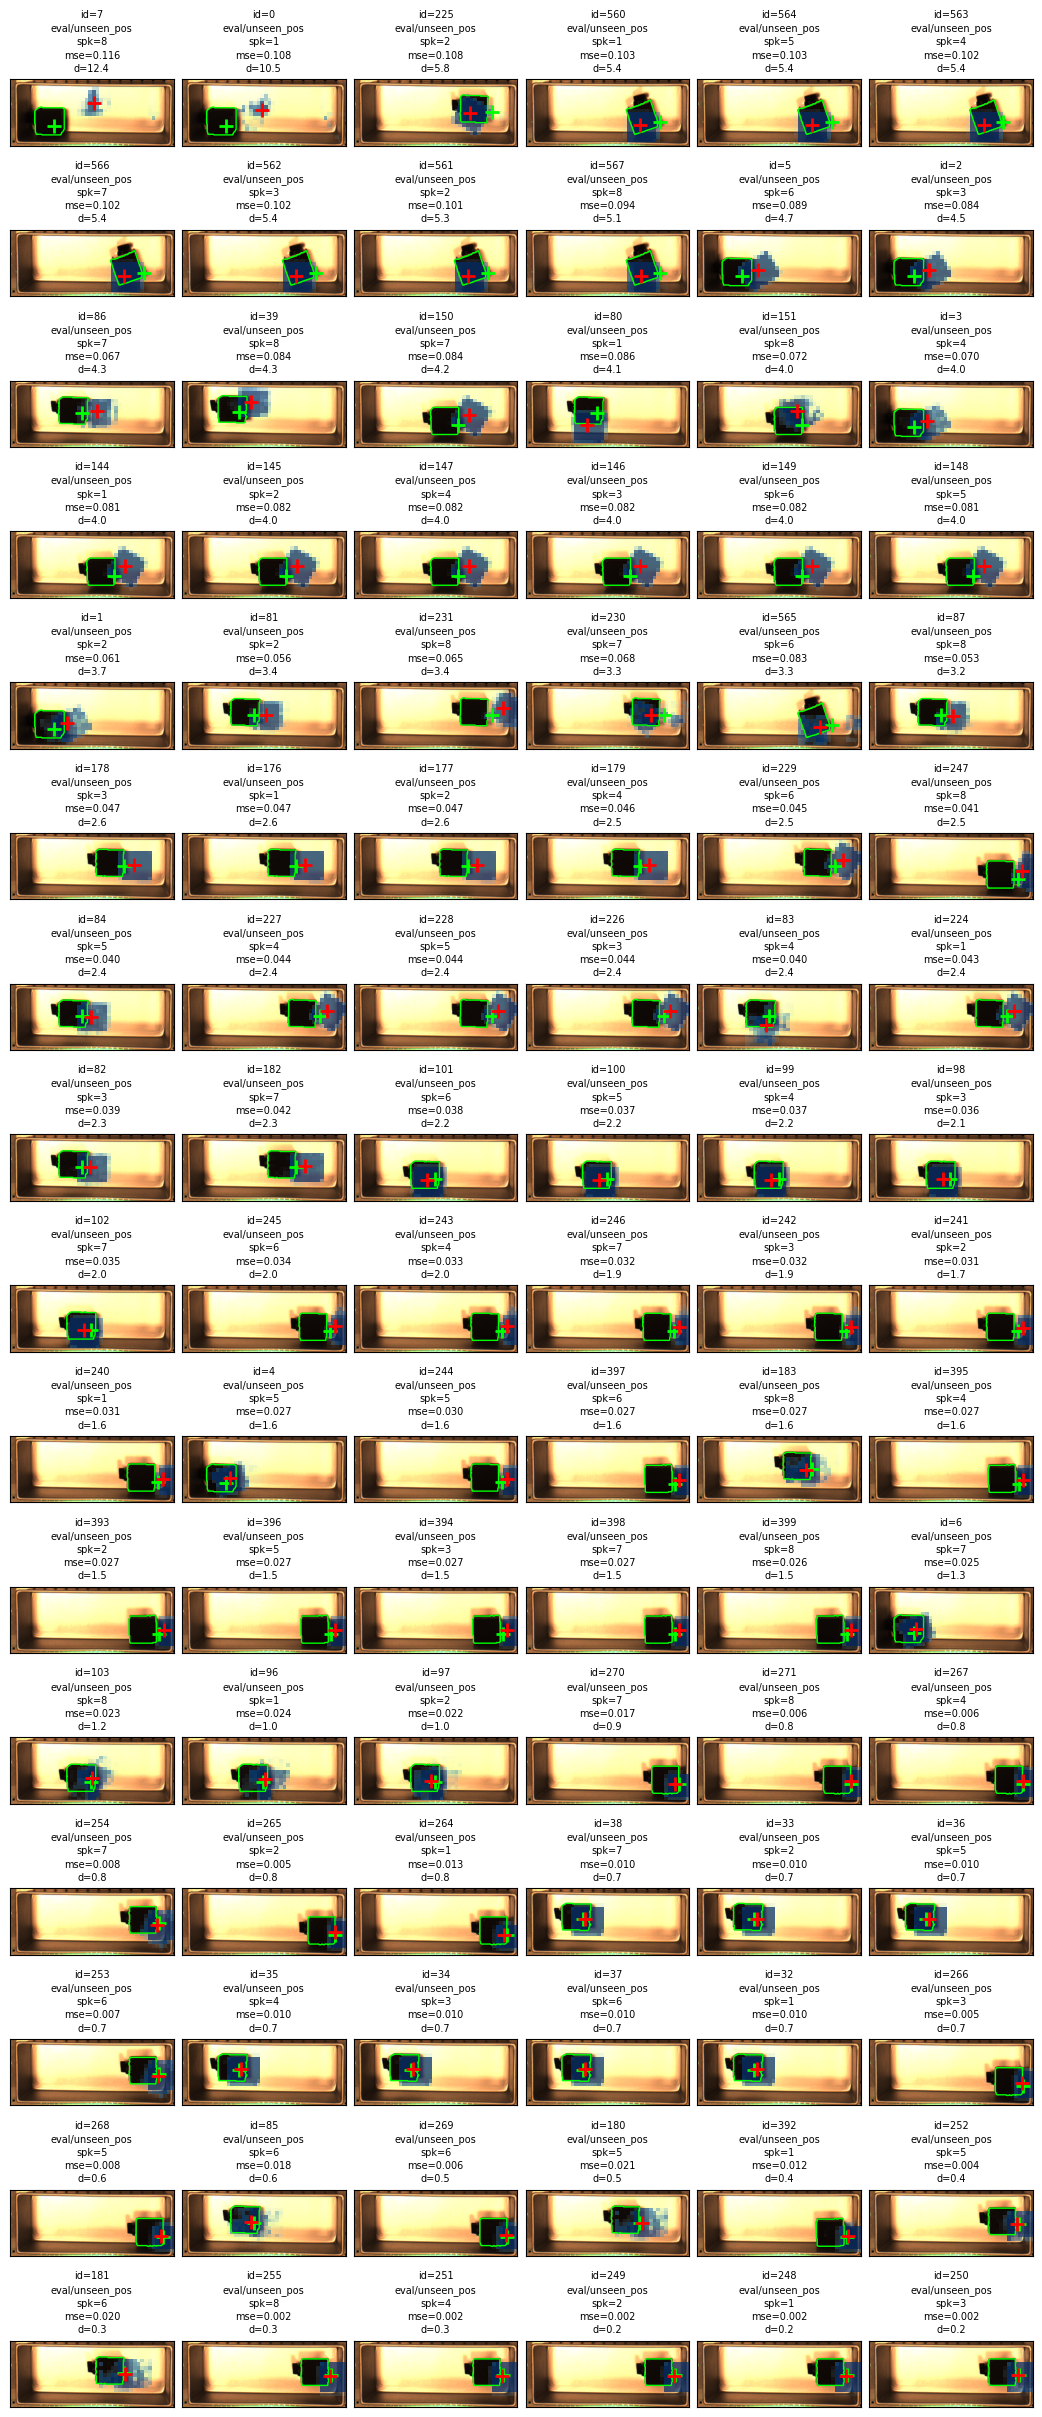

In [50]:
plt.close()
plot_predictions(df, split='eval/unseen_pos')

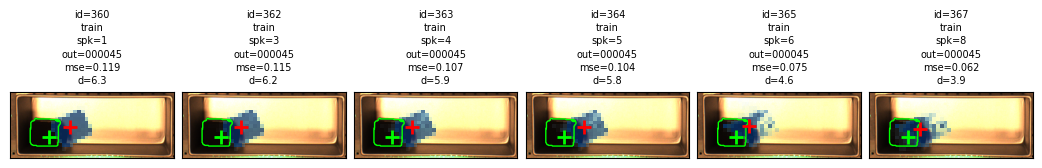

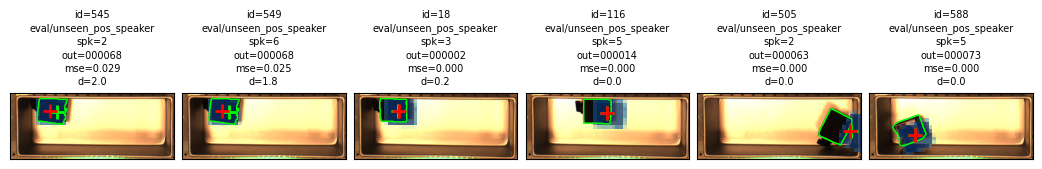

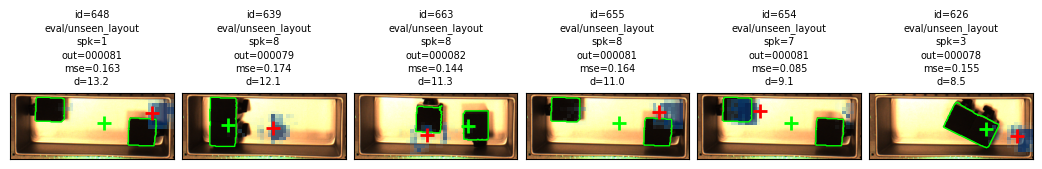

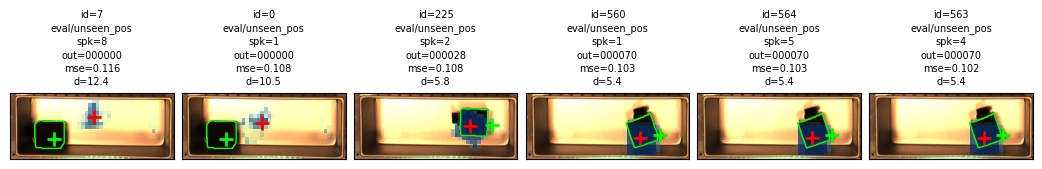

In [21]:
plt.close()
for split in SPLITS: plot_predictions(df, split=split, max_samples=6)

# 5. FFT magnitude spectra

In [22]:
def plot_fft_magnitudes(df, speaker=None, split=None, n_objects=None, box=None,
                        sample_id=None, x_com=None, y_com=None,
                        agg='mean', laser_idx=None,
                        log_y=False, title=None, max_samples=None):
    """
    Plot processed FFT magnitude 'spectra' (already patchified: (L, P, PS, 2)).
    Uses the x-channel (index 0) and flattens patches back to a 1D sequence per laser
    for a rough view — use RAW_DATA_DIR + raw_fft_paths for true unprocessed spectra.

    agg: 'mean' | 'median' | 'max' — how to aggregate across lasers (ignored if laser_idx set)
    laser_idx: int or list of ints — plot specific laser(s) individually instead of aggregating
    """
    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=None, max_samples=max_samples)
    if sdf.empty:
        print('No samples match the filter.')
        return

    fig = go.Figure()
    for _, row in sdf.iterrows():
        sid = int(row['sample_id'])
        fft = tensor_store[sid]['fft']  # (L, P, PS, 2)
        L, P, PS, _ = fft.shape
        mag = fft[..., 0].reshape(L, P * PS)  # (L, F) using x-channel

        if laser_idx is not None:
            idxs = [laser_idx] if isinstance(laser_idx, int) else list(laser_idx)
            spectrum = mag[idxs].mean(0)
        elif agg == 'mean':
            spectrum = mag.mean(0)
        elif agg == 'median':
            spectrum = np.median(mag, axis=0)
        elif agg == 'max':
            spectrum = mag.max(0)

        fig.add_trace(go.Scatter(y=spectrum, mode='lines', name=f'id={sid}', opacity=0.7))

    fig.update_layout(title=title or 'FFT magnitude (processed X, x-channel)',
                      xaxis_title='freq bin', yaxis_title='magnitude',
                      yaxis_type='log' if log_y else 'linear', height=400)
    fig.show()

In [23]:
plot_fft_magnitudes(df, split='train', max_samples=8)

# 6. How does position in the box impact error?

In [24]:
def plot_com_error_heatmap(df, metric='com_dist', agg='mean', speaker=None,
                           split=None, n_objects=None, box=None, sample_id=None,
                           x_com=None, y_com=None,
                           vmax=None, title=None, max_samples=None):
    """
    2D heatmap on the bin_cx / bin_cy grid (binned true COM positions).
    Color = agg(metric) per cell. Count annotation shown in each cell.

    metric: any df column, e.g. 'com_dist', 'mse', 'x_com_diff', 'y_com_diff'
    agg:    'mean', 'median', 'max', 'min', 'std'
    """
    sdf = filter_df(df, split=split, speaker=speaker, n_objects=n_objects, box=box,
                    sample_id=sample_id, x_com=x_com, y_com=y_com, sort_by=None, max_samples=max_samples)
    sdf = sdf.dropna(subset=['bin_cx', 'bin_cy', metric])
    if sdf.empty:
        print('No samples match the filter.')
        return

    xs = sorted(sdf['bin_cx'].unique())
    ys = sorted(sdf['bin_cy'].unique())
    nx, ny = len(xs), len(ys)
    x_idx = {v: i for i, v in enumerate(xs)}
    y_idx = {v: i for i, v in enumerate(ys)}

    agg_fn = {'mean': np.mean, 'median': np.median, 'max': np.max, 'min': np.min, 'std': np.std}[agg]

    z    = np.full((ny, nx), float('nan'))
    text = np.full((ny, nx), '', dtype=object)

    for (bx, by), grp in sdf.groupby(['bin_cx', 'bin_cy']):
        i, j = y_idx[by], x_idx[bx]
        z[i, j] = agg_fn(grp[metric])
        text[i, j] = f'n={len(grp)}'

    default_title = f'{agg}({metric})'
    if split is not None: default_title += f'  [{split}]'

    fig = go.Figure(go.Heatmap(z=z, x=xs, y=ys, text=text, texttemplate='%{text}',
                               colorscale='Oranges', zmax=vmax))
    fig.update_layout(title=title or default_title, xaxis_title='bin_cx', yaxis_title='bin_cy',
                      yaxis_autorange='reversed', height=450)
    fig.show()

In [25]:
if 'com_dist' in df.columns:
    for split in SPLITS:
        if split == 'train': continue
        plot_com_error_heatmap(df, split=split)
else:
    print('No inference run loaded — com_dist unavailable in dataset-only mode.')

# 7. Raw sample table

In [26]:
df2 = filter_df(df)
cols = [c for c in ['sample_id', 'split', 'n_objects', 'speakers', 'box', 'mse', 'pred_x_com', 'pred_y_com',
                    'true_x_com', 'true_y_com', 'x_com_diff', 'y_com_diff', 'com_dist'] if c in df2.columns]
df2[cols]

,sample_id,split,n_objects,speakers,box,mse,pred_x_com,pred_y_com,true_x_com,true_y_com,x_com_diff,y_com_diff,com_dist
648,648,eval/unseen_layout,2,1,metal,1.632159e-01,38.165456,5.503102,25.233858,8.181975,12.931598,-2.678873,13.206157
7,7,eval/unseen_pos,1,8,metal,1.157854e-01,22.698898,6.556953,11.927178,12.635312,10.771720,-6.078359,12.368363
639,639,eval/unseen_layout,2,8,metal,1.738569e-01,24.489829,9.547134,12.409141,8.727358,12.080689,0.819776,12.108471
663,663,eval/unseen_layout,2,8,metal,1.438430e-01,19.804197,11.529090,30.820154,8.957178,-11.015958,2.571912,11.312208
655,655,eval/unseen_layout,2,8,metal,1.643807e-01,35.878678,5.378034,25.233858,8.181975,10.644820,-2.803941,11.007919
...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,683,train,0,4,metal,9.043525e-10,23.572158,8.838580,NaN,NaN,NaN,NaN,NaN
684,684,train,0,5,metal,1.115033e-08,17.112191,7.156526,NaN,NaN,NaN,NaN,NaN
685,685,train,0,6,metal,7.228135e-09,15.067786,7.876263,NaN,NaN,NaN,NaN,NaN
686,686,eval/unseen_pos_speaker,0,7,metal,4.162837e-09,21.207841,8.882478,NaN,NaN,NaN,NaN,NaN


# 8. COM distance by speaker, grouped by split

In [43]:
# Fixed categorical order + hues (never cycled/reassigned) so a split keeps its color
# across figures even if some splits are missing from a given df.
SPLIT_COLORS = {
    'train':                   '#2a78d6',  # blue
    'eval/unseen_pos_speaker': '#1baf7a',  # aqua
    'eval/unseen_layout':      '#eda100',  # yellow
    'eval/unseen_pos':         '#4a3aa7',  # violet
}

# 8 fixed categorical hues (validated ordering) for speaker identity when speaker is the
# grouped/colored series instead of the x-axis.
SPEAKER_COLORS = {
    1: '#2a78d6', 2: '#1baf7a', 3: '#eda100', 4: '#008300',
    5: '#4a3aa7', 6: '#e34948', 7: '#e87ba4', 8: '#eb6834',
}

def plot_com_dist_grouped(df, x='speakers', group_by='split', metric='com_dist', title=None):
    """
    Grouped bar chart: `x` on the x-axis, one bar per `group_by` value (fixed color per
    value), bar height = mean(metric), error bar = std(metric). Plotly clusters bars
    sharing an x-value automatically (barmode='group'); missing (x, group_by) combos
    become gaps. Each bar is labeled with mean±std; hovering also shows n (sample count)
    since the label alone can't convey how many samples backed a given bar.

    x, group_by: 'speakers' or 'split' (use one for each — this covers both directions:
    speaker-on-x/split-colored, or split-on-x/speaker-colored).
    """
    color_map = {'split': SPLIT_COLORS, 'speakers': SPEAKER_COLORS}[group_by]
    sdf = df.dropna(subset=[x, group_by, metric])
    if sdf.empty:
        print('No samples with', x, group_by, 'and', metric)
        return

    x_vals = sorted(sdf[x].unique(), key=str) if x != 'split' else \
             [s for s in SPLIT_COLORS if s in sdf[x].unique()]
    group_vals = [g for g in color_map if g in sdf[group_by].unique()] if group_by == 'split' \
                 else sorted(sdf[group_by].unique())

    fig = go.Figure()
    for g in group_vals:
        means, stds, ns = [], [], []
        for xv in x_vals:
            vals = sdf.loc[(sdf[x] == xv) & (sdf[group_by] == g), metric]
            means.append(vals.mean() if len(vals) else np.nan)
            stds.append(vals.std() if len(vals) else np.nan)
            ns.append(len(vals))
        fig.add_trace(go.Bar(
            x=[str(v) for v in x_vals], y=means, name=str(g),
            marker_color=color_map.get(g, '#898781'),
            error_y=dict(type='data', array=stds, color='#52514e', thickness=1, width=3),
            text=[f'{m:.2f}±{s:.2f}' if not np.isnan(m) else '' for m, s in zip(means, stds)],
            textposition='outside',
            customdata=np.stack([stds, ns], axis=-1),
            hovertemplate=(f'{group_by}={g}<br>{x}=%{{x}}<br>mean {metric}=%{{y:.3f}}'
                           '<br>std=%{customdata[0]:.3f}<br>n=%{customdata[1]:.0f}<extra></extra>'),
        ))

    fig.update_layout(
        barmode='group', bargap=0.2, bargroupgap=0.1,
        title=title or f'{metric} by {x}, grouped by {group_by}',
        xaxis_title=x, yaxis_title=f'mean {metric}',
        legend_title=group_by, height=450, width=1600,
    )
    fig.show()

# back-compat alias for the original speaker-on-x / split-colored call sites
def plot_com_dist_by_speaker(df, splits=None, metric='com_dist', title=None):
    plot_com_dist_grouped(df, x='speakers', group_by='split', metric=metric, title=title)

In [44]:
if 'com_dist' in df.columns:
    plot_com_dist_grouped(df, x='speakers', group_by='split')
    plot_com_dist_grouped(df, x='split', group_by='speakers')
else:
    print('No inference run loaded — com_dist unavailable in dataset-only mode.')